# 多品种绩效对比 — 同一截止日期不同版本

固定训练截止日期 **2025-07-01**，对比 **v0** 和 **v1** 两个版本的表现。


In [1]:
# ==================== 全局配置 ====================
SYMBOLS = ["A", "B", "C", "CS", "M", "Y", "P", "LH"]
TRAIN_END_DATES = ["2025-07-01"]   # 固定日期
VERSIONS = ["v0", "v1"]            # 要对比的两个版本

train_label = 5
bt_start = "2025-07-01"
bt_end = "2026-07-01"

bt_params = {
    "th1": 0.9, "th2": 0.5, "holding_bars": 10,
    "holding_days": 5, "fee": 0, "v": 2,
}

# 模型根目录（20250701 实验目录）
model_base_dir = "/home/strategy_res/single/dce_农/20250701/model"
output_dir = "./eval_cross_version"


In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append("/home/future_commodity")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from multi_symbol_eval import MultiSymbolEvaluator


In [ ]:
ev = MultiSymbolEvaluator(
    model_base_dir=model_base_dir,
    bt_start=bt_start, bt_end=bt_end,
    bt_params=bt_params, output_dir=output_dir, money="auto",
)

ev.run_batch(
    symbols=SYMBOLS, train_end_dates=TRAIN_END_DATES,
    versions=VERSIONS, train_label=train_label,
    n_jobs=4,
)


并行回测: 16 组任务, n_jobs=4


回测进度:   0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
summary = ev.get_summary_df()
summary


,symbol,train_end_date,version,annual_ret,sharpe,max_dd,win_rate,trade_count,avg_position,long_contrib,short_contrib,days,start_date,end_date
0,A,2025-07-01,v0,0.004936,1.431174,-0.228192,0.577670,5673,0.412812,-0.010830,-0.013834,206,2025-07-01,2026-07-01
1,A,2025-07-01,v1,0.002245,0.671303,-0.242292,0.543689,4775,0.428360,-0.011142,-0.013142,206,2025-07-01,2026-07-01
2,B,2025-07-01,v1,0.012560,4.642794,-0.057352,0.626214,6568,0.417933,-0.014962,-0.007995,206,2025-07-01,2026-07-01
3,B,2025-07-01,v0,0.011733,3.983134,-0.143323,0.626214,5617,0.418175,-0.003438,0.001505,206,2025-07-01,2026-07-01
4,C,2025-07-01,v0,0.012316,9.531979,-0.030233,0.762136,7981,0.403298,-0.003458,-0.003563,206,2025-07-01,2026-07-01
5,C,2025-07-01,v1,0.007710,6.499249,-0.046179,0.694175,6787,0.406807,-0.005206,-0.004874,206,2025-07-01,2026-07-01
6,CS,2025-07-01,v0,0.006967,4.377913,-0.083941,0.611650,8297,0.398962,-0.008117,-0.009371,206,2025-07-01,2026-07-01
7,CS,2025-07-01,v1,0.006818,4.536595,-0.083358,0.626214,7088,0.396908,-0.007712,-0.008196,206,2025-07-01,2026-07-01
8,LH,2025-07-01,v0,0.109435,5.708413,-0.373543,0.653659,3840,0.408897,0.002927,-0.007067,205,2025-07-01,2026-07-01
9,LH,2025-07-01,v1,0.085652,4.837567,-0.627542,0.673171,3368,0.408658,-0.023624,-0.013285,205,2025-07-01,2026-07-01


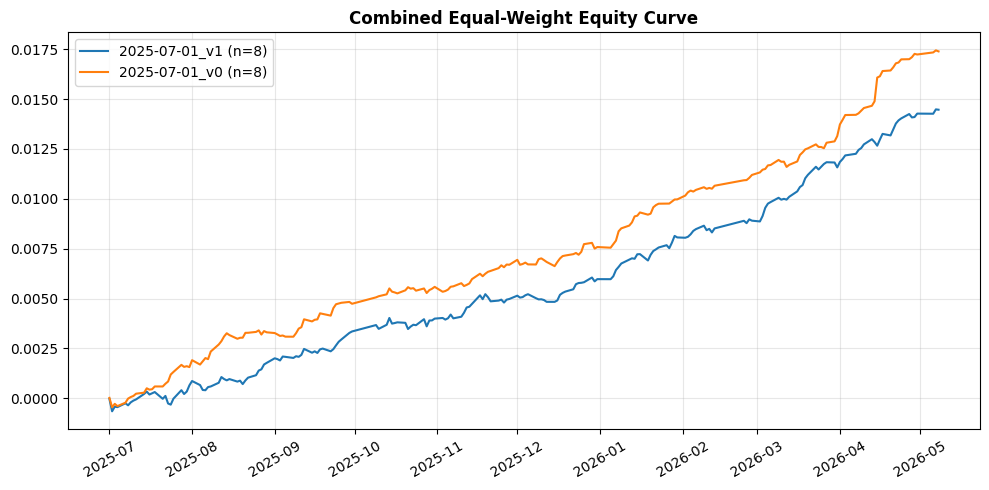

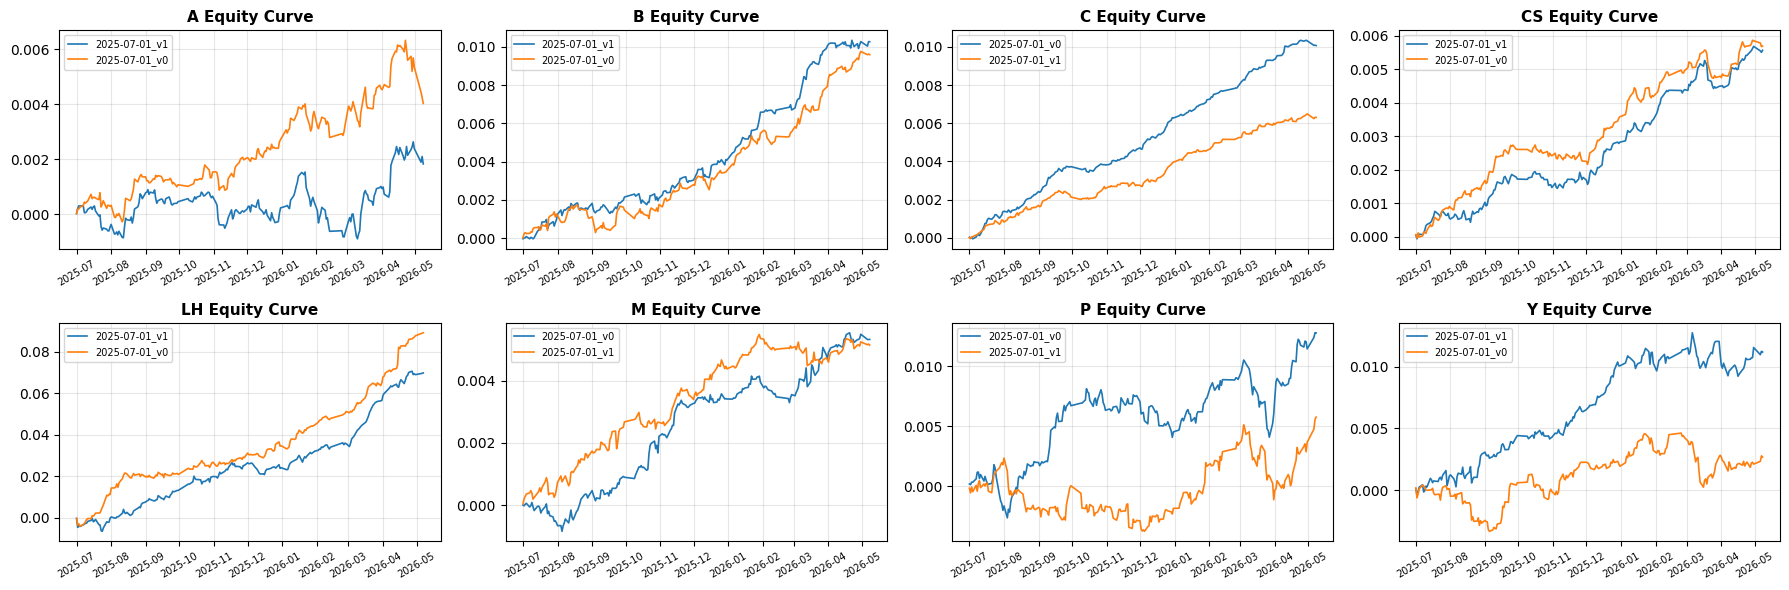

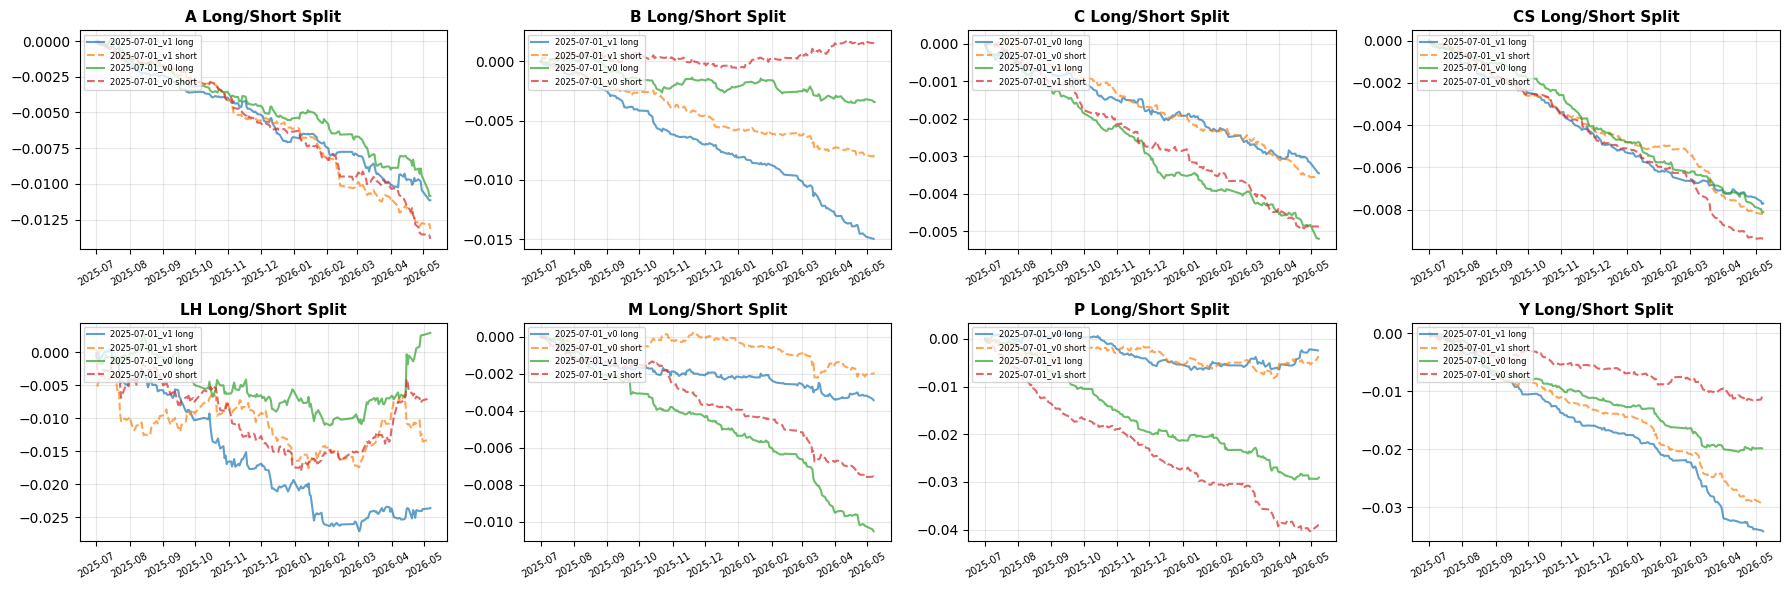

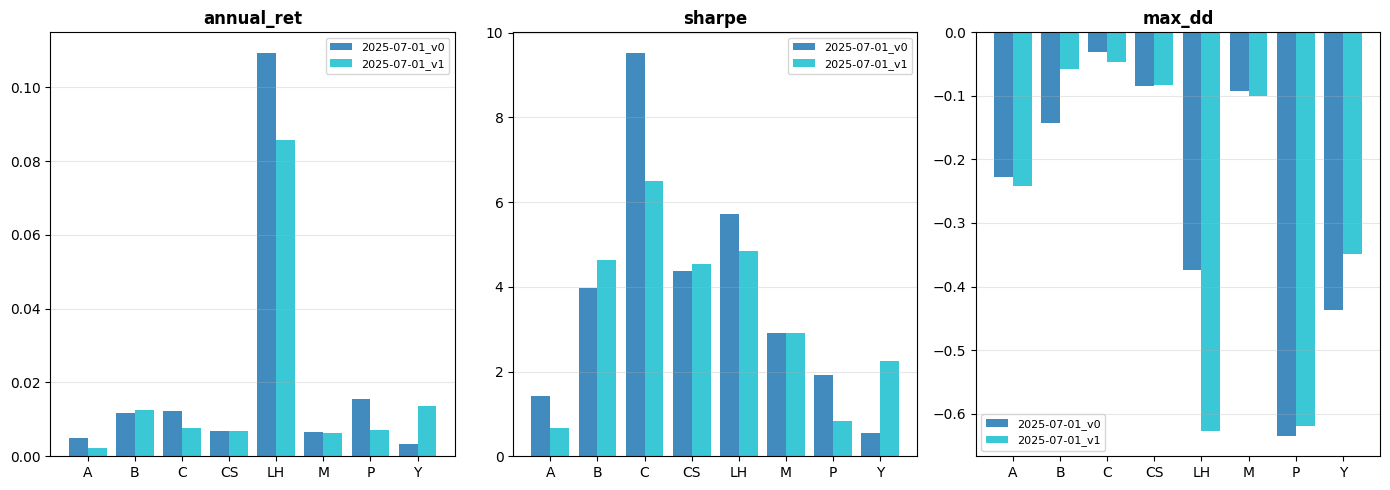

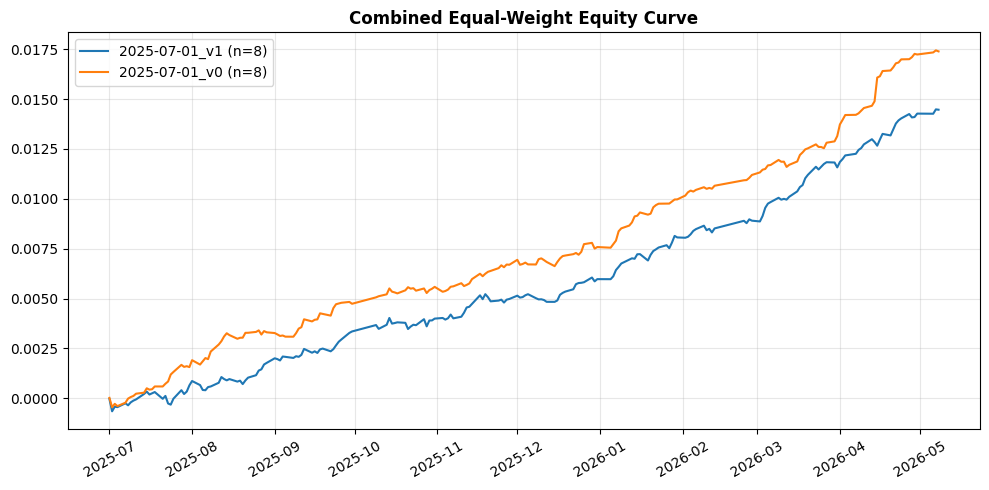

In [ ]:
ev.save_summary_csv()
ev.plot_equity_curves()
ev.plot_metrics_bar()
ev.plot_combined_equity()
